In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans , DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


In [2]:
df = pd.read_csv(r"C:\Users\sumit\Downloads\archive\Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
df.columns = df.columns.str.strip()

df = df.drop_duplicates()

for col in df.columns:
    if col != "country":
        df[col] = pd.to_numeric(df[col] , errors="coerce")

df.fillna(df.median(numeric_only= True) , inplace = True)
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB
None


In [4]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [5]:
X = df.drop("country" , axis = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
inertia = []

for k in range(2,11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_scaled)
    inertia.append(model.inertia_)
    

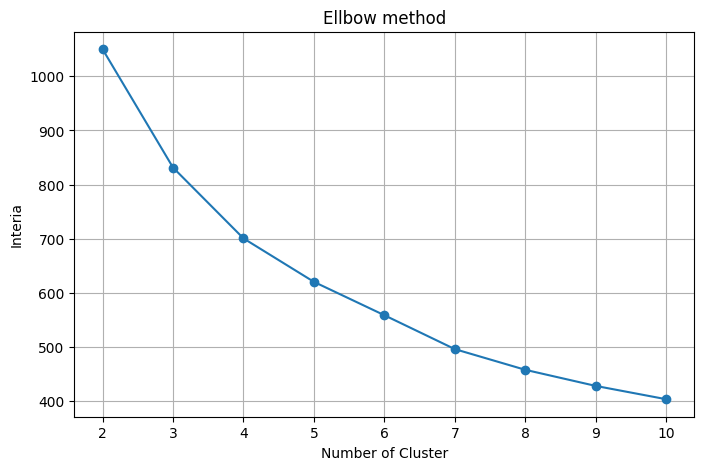

In [7]:
plt.figure(figsize=(8,5))
plt.plot(range(2,11) , inertia , marker = 'o')

plt.xlabel("Number of Cluster")
plt.ylabel("Interia")
plt.title("Ellbow method")

plt.grid(True)
plt.show()

In [8]:
best_k = 3
kmeans = KMeans(
    n_clusters= best_k,
    random_state=42,
    n_init=10
)
labels = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = labels

In [9]:
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,KMeans_Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2
...,...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,2
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,2
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,2
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310,1


In [10]:
score = silhouette_score(X_scaled , labels)
print("silhouette_score :",score)

silhouette_score : 0.28329575683463126


In [11]:
dbscan = DBSCAN(
    eps = 1.5,
    min_samples=5
)
db_labels = dbscan.fit_predict(X_scaled)
df["DBSCAN_Cluster"] = db_labels
print(df["DBSCAN_Cluster"].value_counts())

DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

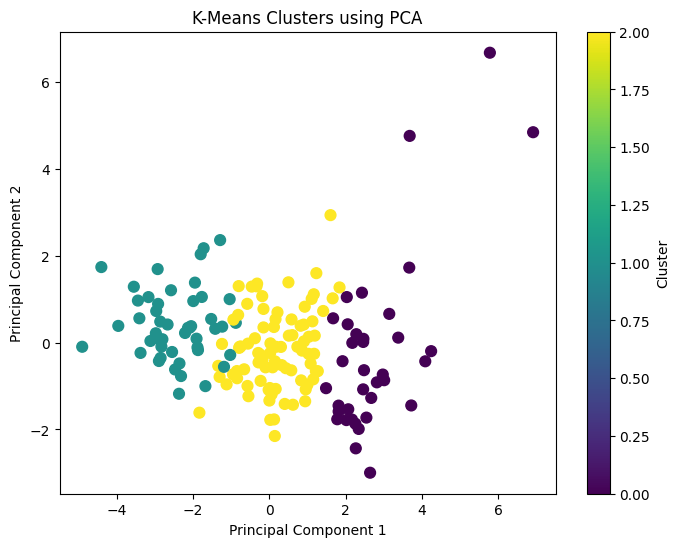

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels,
    cmap='viridis',
    s=60
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters using PCA")

plt.colorbar(label="Cluster")

plt.show()

In [14]:
summary = df.groupby("KMeans_Cluster").mean(numeric_only=True)

summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,-0.250000
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979,-0.340426
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381,-0.059524


In [15]:
for cluster in sorted(df["KMeans_Cluster"].unique()):
    print("\nCluster", cluster)
    print(df[df["KMeans_Cluster"] == cluster]["country"].tolist())


Cluster 0
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Japan', 'Kuwait', 'Luxembourg', 'Malta', 'Netherlands', 'New Zealand', 'Norway', 'Portugal', 'Qatar', 'Singapore', 'Slovak Republic', 'Slovenia', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'United Arab Emirates', 'United Kingdom', 'United States']

Cluster 1
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Iraq', 'Kenya', 'Kiribati', 'Lao', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Pakistan', 'Rwanda', 'Senegal', 'Sierra Leone', 'South Africa', 'Sudan', 'Tanzania', 'Timor-Leste', 'To

# Observations

1. The K-Means algorithm grouped the countries into **three socio-economic clusters**, representing developed, developing, and underdeveloped nations.

2. One cluster is characterized by **high income, high life expectancy, and low child mortality**, indicating economically advanced countries with better healthcare and living standards.

3. Another cluster contains countries with **high child mortality, low GDP per capita, and lower life expectancy**, representing low-development regions that require greater economic and healthcare improvements.

4. The remaining cluster represents **developing economies** with moderate income levels, average health indicators, and improving socio-economic conditions.

5. The **Silhouette Score (0.2833)** indicates a **reasonable clustering structure**, while the **PCA visualization** shows distinguishable country groups with some overlap, which is expected for real-world socio-economic datasets.